In [1]:
import pandas as pd
import numpy as np

In [2]:
garment = pd.read_csv("../202618043_LAB05/data/garments_worker_productivity.csv")
garment.head(5)
garment.info()
garment.shape
garment.columns

FileNotFoundError: [Errno 2] No such file or directory: '../202618043_LAB05/data/garments_worker_productivity.csv'

In [ ]:
garment.isnull().sum()


date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [ ]:
garment = garment.drop(columns = 'date') # date coumns drop

In [ ]:
garment["MeetsTarget"] = ( # check which instances meet the targeted productitvity
    garment["actual_productivity"] >= garment["targeted_productivity"]
).astype(int) 

In [ ]:
print(garment[[
    "targeted_productivity",
    "actual_productivity",
    "MeetsTarget"
]].head(10))

   targeted_productivity  actual_productivity  MeetsTarget
0                   0.80             0.940725            1
1                   0.75             0.886500            1
2                   0.80             0.800570            1
3                   0.80             0.800570            1
4                   0.80             0.800382            1
5                   0.80             0.800125            1
6                   0.75             0.755167            1
7                   0.75             0.753683            1
8                   0.75             0.753098            1
9                   0.75             0.750428            1


In [ ]:
print(garment["MeetsTarget"].value_counts())
print(garment["MeetsTarget"].value_counts(normalize=True))

MeetsTarget
1    875
0    322
Name: count, dtype: int64
MeetsTarget
1    0.730994
0    0.269006
Name: proportion, dtype: float64


In [ ]:
numeric_cols = [ # checkinng the data distribution 
    "team",
    "targeted_productivity",
    "smv",
    "wip",
    "over_time",
    "incentive",
    "idle_time",
    "idle_men",
    "no_of_style_change",
    "no_of_workers"
]

print(garment[numeric_cols].describe().T)

                        count         mean          std   min      25%  \
team                   1197.0     6.426901     3.463963  1.00     3.00   
targeted_productivity  1197.0     0.729632     0.097891  0.07     0.70   
smv                    1197.0    15.062172    10.943219  2.90     3.94   
wip                     691.0  1190.465991  1837.455001  7.00   774.50   
over_time              1197.0  4567.460317  3348.823563  0.00  1440.00   
incentive              1197.0    38.210526   160.182643  0.00     0.00   
idle_time              1197.0     0.730159    12.709757  0.00     0.00   
idle_men               1197.0     0.369256     3.268987  0.00     0.00   
no_of_style_change     1197.0     0.150376     0.427848  0.00     0.00   
no_of_workers          1197.0    34.609858    22.197687  2.00     9.00   

                           50%      75%       max  
team                      6.00     9.00     12.00  
targeted_productivity     0.75     0.80      0.80  
smv                      15.2

In [ ]:
categorical_cols = [
    "quarter",
    "department",
    "day"
]


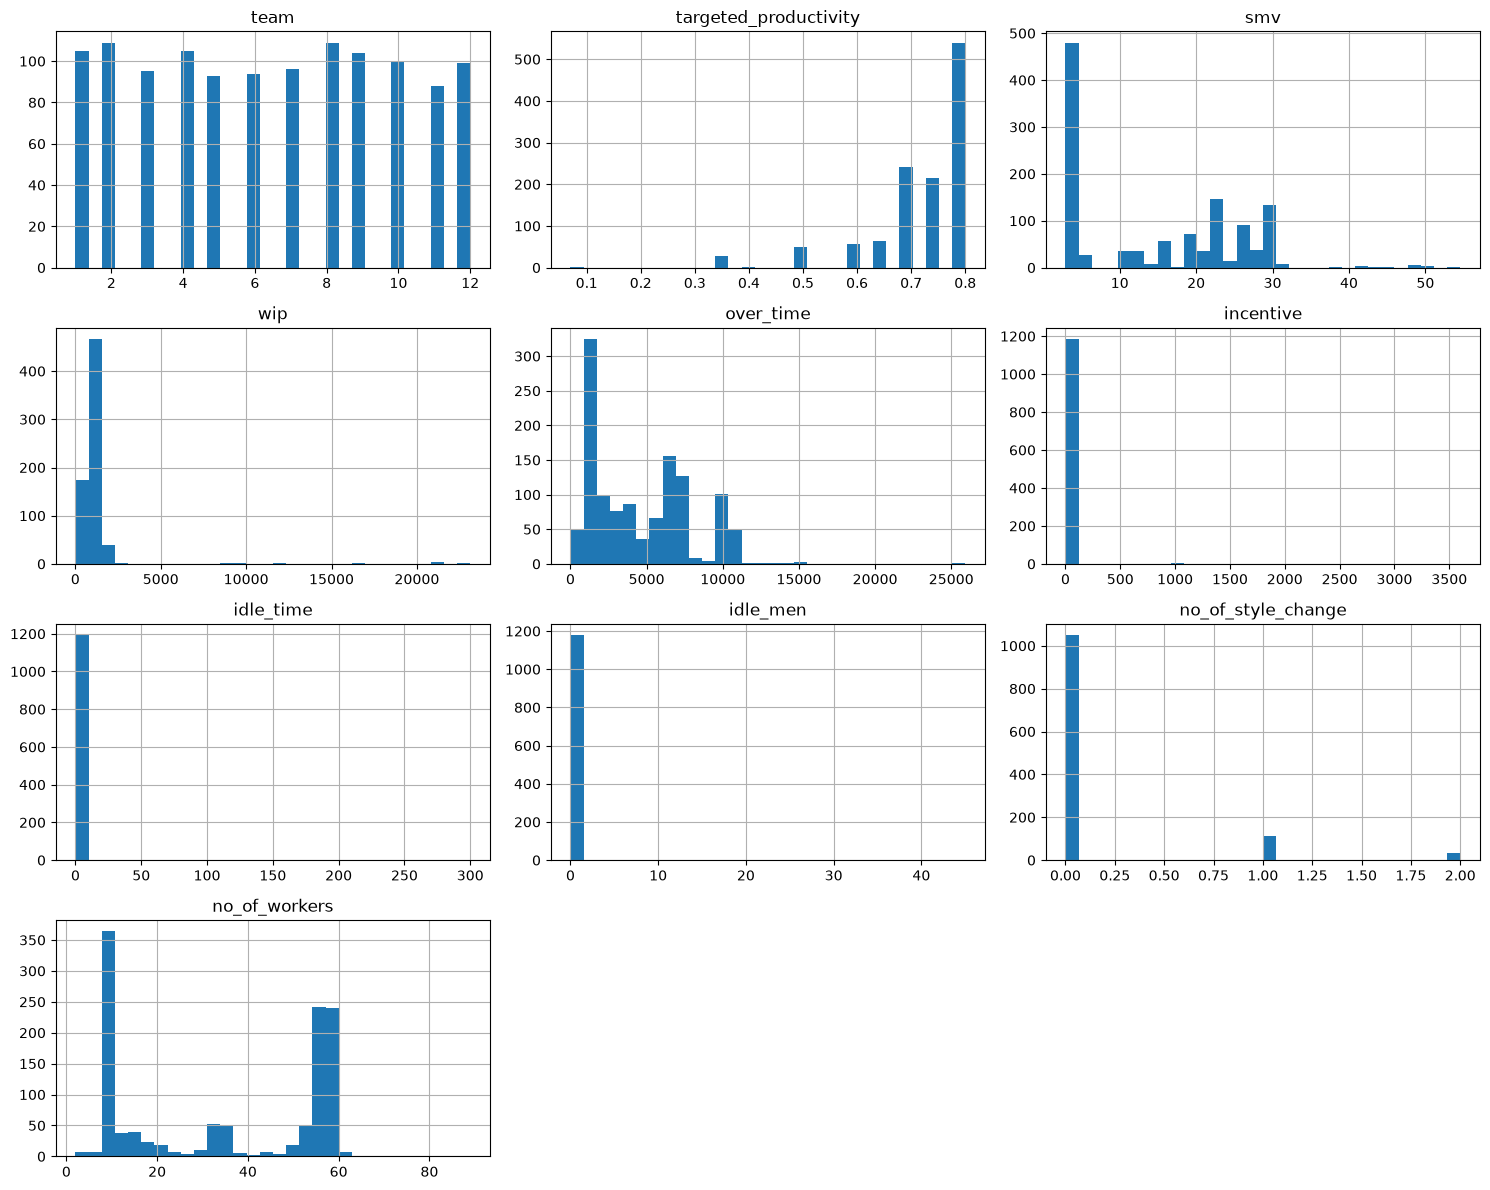

In [ ]:
import matplotlib.pyplot as plt

numeric_cols = [
    "team",
    "targeted_productivity",
    "smv",
    "wip",
    "over_time",
    "incentive",
    "idle_time",
    "idle_men",
    "no_of_style_change",
    "no_of_workers"
]

garment[numeric_cols].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression

In [ ]:
train_idx, test_idx = train_test_split(
    garment.index,
    test_size=0.2,
    random_state=42
)

In [ ]:
X = garment.drop(columns=["actual_productivity", "MeetsTarget"])
y = garment["actual_productivity"]

In [ ]:
X_train = X.loc[train_idx]
X_test = X.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (957, 13)
X_test : (240, 13)
y_train: (957,)
y_test : (240,)


In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [ ]:
regression_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [ ]:
import time

start_time = time.perf_counter()

regression_pipeline.fit(X_train, y_train)

training_time = time.perf_counter() - start_time

print("Training time:", training_time, "seconds")

Training time: 0.033799700000145094 seconds


In [ ]:
regression_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['quarter','department','day',...,'idle_men','no_of_style_change', 'no_of_workers']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subse

In [ ]:
start_time = time.perf_counter()

y_pred = regression_pipeline.predict(X_test)

prediction_time = time.perf_counter() - start_time

print("Prediction time:", prediction_time, "seconds")

Prediction time: 0.012926100000186125 seconds


In [ ]:
print("Actual values:")
print(y_test.head())

print("\nPredicted values:")
print(y_pred[:5])

Actual values:
921    0.268214
321    0.800359
101    0.681061
920    0.325000
58     0.667604
Name: actual_productivity, dtype: float64

Predicted values:
[0.62391331 0.77049036 0.82839304 0.73502695 0.81634848]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.10845261337977505
RMSE: 0.14861757809593648
R²  : 0.16816825663056223


In [ ]:
regression_result = pd.DataFrame({
    "Model": ["Scikit-learn Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Training Time (s)": [training_time],
    "Prediction Time (s)": [prediction_time]
})

regression_result

,Model,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn Linear Regression,0.108453,0.148618,0.168168,0.0338,0.012926


In [ ]:
X_clf = garment.drop(
    columns=["actual_productivity", "MeetsTarget"]
)

y_clf = garment["MeetsTarget"]

In [ ]:
X_clf_train = X_clf.loc[train_idx]
X_clf_test = X_clf.loc[test_idx]

y_clf_train = y_clf.loc[train_idx]
y_clf_test = y_clf.loc[test_idx]

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
classification_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [ ]:
import time

start_time = time.perf_counter()

classification_pipeline.fit(
    X_clf_train,
    y_clf_train
)

training_time_clf = time.perf_counter() - start_time

print("Training time:", training_time_clf, "seconds")

Training time: 0.06686500000023443 seconds


In [ ]:
classification_pipeline.fit(
    X_clf_train,
    y_clf_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['quarter','department','day',...,'idle_men','no_of_style_change', 'no_of_workers']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthro

In [ ]:
start_time = time.perf_counter()

y_clf_pred = classification_pipeline.predict(X_clf_test)

prediction_time_clf = time.perf_counter() - start_time

print("Prediction time:", prediction_time_clf, "seconds")

Prediction time: 0.014004099999965547 seconds


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_clf_test, y_clf_pred)

precision = precision_score(y_clf_test, y_clf_pred)

recall = recall_score(y_clf_test, y_clf_pred)

f1 = f1_score(y_clf_test, y_clf_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.775
Precision: 0.7808219178082192
Recall   : 0.9661016949152542
F1-score : 0.8636363636363636


In [ ]:
from IPython.display import display

classification_result = pd.DataFrame({
    "Model": ["Scikit-learn Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1],
    "Training Time (s)": [training_time_clf],
    "Prediction Time (s)": [prediction_time_clf]
})

regression_result = pd.DataFrame({
    "Model": ["Scikit-learn Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Training Time (s)": [training_time],
    "Prediction Time (s)": [prediction_time]
})

display(classification_result)
display(regression_result)

,Model,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s)
0,Scikit-learn Logistic Regression,0.775,0.780822,0.966102,0.863636,0.066865,0.014004


,Model,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn Linear Regression,0.108453,0.148618,0.168168,0.0338,0.012926


using then normall equation 

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to NumPy array if necessary
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

In [ ]:
X_train_np = np.c_[ #adding the 1 column in matrix
    np.ones(X_train_processed.shape[0]),
    X_train_processed
]

X_test_np = np.c_[
    np.ones(X_test_processed.shape[0]),
    X_test_processed
]

In [ ]:
import time

start_time = time.perf_counter()

beta = np.linalg.inv(
    X_train_np.T @ X_train_np
) @ X_train_np.T @ y_train.to_numpy()

training_time_manual = time.perf_counter() - start_time

print("Training time:", training_time_manual, "seconds")

Training time: 0.007912099999884958 seconds


In [ ]:
print("Number of coefficients:", len(beta))
print("Coefficients:")
print(beta)

Number of coefficients: 25
Coefficients:
[-2.39143792 -0.00399781  0.13206009 -0.05909616 -0.06627066  0.12859058
 -0.07718321  0.0077354  -0.0199539   0.02012776  0.29443437 -0.37877853
 -0.61184811 -0.24098823 -0.3156541   0.49939226  1.77434205  1.49294299
  0.64713766  2.61856944  0.54490505  1.17399002  0.94186782  1.39401071
  1.16878258]


In [ ]:
start_time = time.perf_counter()

y_pred_manual = X_test_np @ beta

prediction_time_manual = time.perf_counter() - start_time

print("Prediction time:", prediction_time_manual, "seconds")

Prediction time: 0.00014379999993252568 seconds


In [ ]:
error = y_test.to_numpy() - y_pred_manual

mae_manual = np.mean(np.abs(error))

rmse_manual = np.sqrt(np.mean(error ** 2))

ss_res = np.sum(error ** 2)
ss_tot = np.sum(
    (y_test.to_numpy() - np.mean(y_train.to_numpy())) ** 2
)

r2_manual = 1 - (ss_res / ss_tot)

print("MAE :", mae_manual)
print("RMSE:", rmse_manual)
print("R²  :", r2_manual)

MAE : 1.1613001487742372
RMSE: 1.2835360046117634
R²  : -60.649558744131085


In [ ]:
comparison = pd.DataFrame({
    "Implementation": [
        "Linear Regression Scikit-learn",
        "Linear Regression From Scratch noramal equation"
    ],
    "Training Time (ms)": [
        training_time * 1000,
        training_time_manual * 1000
    ],
    "Prediction Time (s)": [
        prediction_time * 1000,
        prediction_time_manual * 1000
    ]
})

comparison

,Implementation,Training Time (ms),Prediction Time (s)
0,Linear Regression Scikit-learn,33.7997,12.9261
1,Linear Regression From Scratch noramal equation,7.9121,0.1438


logit regression using gradient descent screact

In [ ]:
X_train_log_manual = X_clf_train.copy()
X_test_log_manual = X_clf_test.copy()

In [ ]:
train_medians = X_train_log_manual[numeric_cols].median()

X_train_log_manual[numeric_cols] = (
    X_train_log_manual[numeric_cols]
    .fillna(train_medians)
)

X_test_log_manual[numeric_cols] = (
    X_test_log_manual[numeric_cols]
    .fillna(train_medians)
)

In [ ]:
X_train_cat = pd.get_dummies(
    X_train_log_manual[categorical_cols],
    dtype=float
)

X_test_cat = pd.get_dummies(
    X_test_log_manual[categorical_cols],
    dtype=float
)

X_test_cat = X_test_cat.reindex(
    columns=X_train_cat.columns,
    fill_value=0
)

In [ ]:
train_mean = X_train_log_manual[numeric_cols].mean()
train_std = X_train_log_manual[numeric_cols].std()

X_train_num = (
    X_train_log_manual[numeric_cols] - train_mean
) / train_std

X_test_num = (
    X_test_log_manual[numeric_cols] - train_mean
) / train_std

In [ ]:
X_train_log_manual = pd.concat(
    [X_train_num, X_train_cat],
    axis=1
)

X_test_log_manual = pd.concat(
    [X_test_num, X_test_cat],
    axis=1
)

In [ ]:
X_train_log = X_train_log_manual.to_numpy(dtype=float)
X_test_log = X_test_log_manual.to_numpy(dtype=float)

y_train_log = y_clf_train.to_numpy(dtype=float)
y_test_log = y_clf_test.to_numpy(dtype=float)

In [ ]:
X_train_log = np.c_[
    np.ones(X_train_log.shape[0]),
    X_train_log
]

X_test_log = np.c_[
    np.ones(X_test_log.shape[0]),
    X_test_log
]

In [ ]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [ ]:
beta = np.zeros(X_train_log.shape[1])

In [ ]:
learning_rate = 0.01
epochs = 500

start_time = time.perf_counter()

m = X_train_log.shape[0]

for epoch in range(epochs):

    z = X_train_log @ beta

    probability = sigmoid(z)

    error = probability - y_train_log

    gradient = (X_train_log.T @ error) / m

    beta = beta - learning_rate * gradient

manual_logistic_train_time = (
    time.perf_counter() - start_time
)

In [ ]:
start_time = time.perf_counter()

z_test = X_test_log @ beta

probabilities = sigmoid(z_test)

manual_logistic_prediction_time = (
    time.perf_counter() - start_time
)

In [ ]:
threshold = 0.5

y_pred_logistic = (
    probabilities >= threshold
).astype(int)

In [ ]:
tp = np.sum(
    (y_test_log == 1) &
    (y_pred_logistic == 1)
)

tn = np.sum(
    (y_test_log == 0) &
    (y_pred_logistic == 0)
)

fp = np.sum(
    (y_test_log == 0) &
    (y_pred_logistic == 1)
)

fn = np.sum(
    (y_test_log == 1) &
    (y_pred_logistic == 0)
)

accuracy_manual = (tp + tn) / len(y_test_log)

precision_manual = (
    tp / (tp + fp)
    if (tp + fp) != 0 else 0
)

recall_manual = (
    tp / (tp + fn)
    if (tp + fn) != 0 else 0
)

f1_manual = (
    2 * precision_manual * recall_manual /
    (precision_manual + recall_manual)
    if (precision_manual + recall_manual) != 0
    else 0
)

In [ ]:
comparison = pd.DataFrame({
    "Implementation": [
        "logit regression Scikit-learn",
        "logit regression From Scratch",
        "Linear Regression Scikit-learn",
        "Linear Regression From Scratch noramal equation"
    ],
    
    "Training Time (ms)": [
        training_time_clf * 1_000,
        manual_logistic_train_time * 1_000,
        training_time * 1000,
        training_time_manual * 1000
    ],
    "Prediction Time (ms)": [
        prediction_time_clf * 1_000,
        manual_logistic_prediction_time * 1_000,
        prediction_time * 1000,
        prediction_time_manual * 1000
    ]
})

display(comparison)

,Implementation,Training Time (ms),Prediction Time (ms)
0,logit regression Scikit-learn,66.8650,14.0041
1,logit regression From Scratch,44.9386,0.3553
2,Linear Regression Scikit-learn,33.7997,12.9261
3,Linear Regression From Scratch noramal equation,7.9121,0.1438
